# stream 1

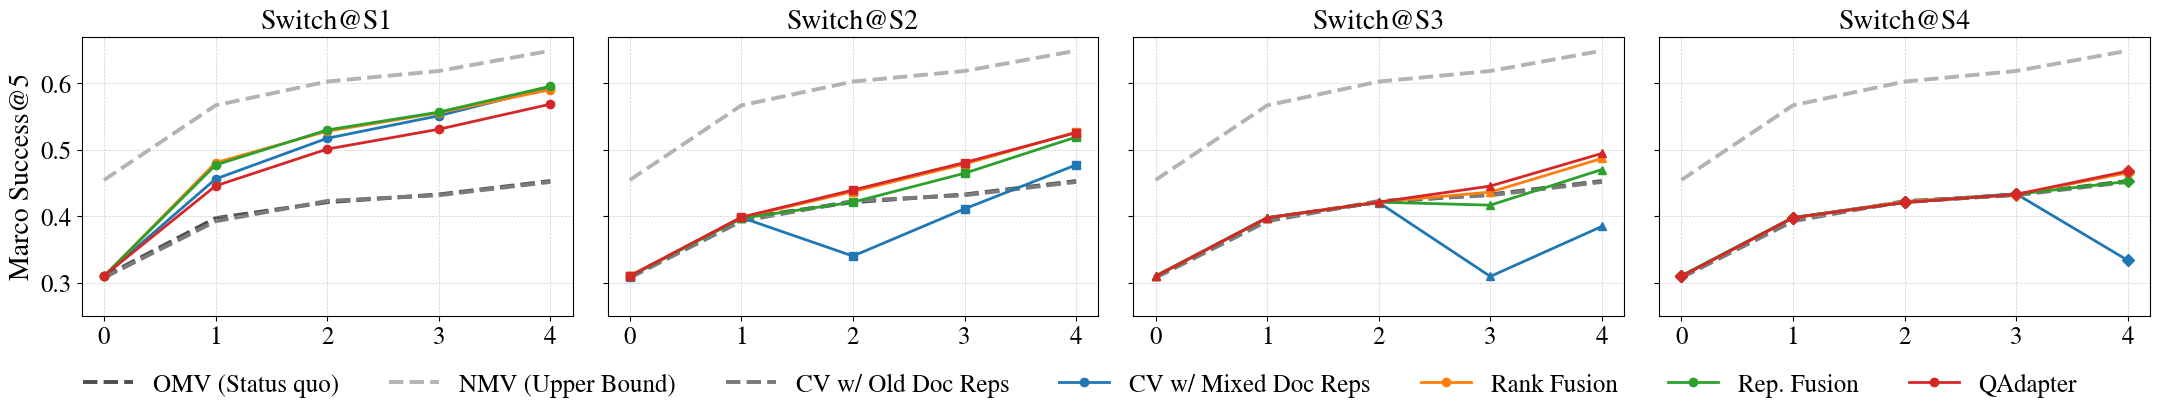

In [1]:
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

# ---- SIGIR/ACM-ish look: Times-like serif + bigger fonts ----
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "Nimbus Roman", "STIXGeneral", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 20,          # 全局默认字号（你想更大就 18/20）
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# X axis
x_labels = ["0", "1", "2", "3", "4"]
x = list(range(len(x_labels)))


sections = {
    "CV w/ Mixed Doc Reps": {
        "old_q/old_d (Lower Bound)": [0.3088, 0.397, 0.4211, 0.4327, 0.4529],
        "new_q/new_d (Upper Bound)": [0.4545, 0.567, 0.6029, 0.6188, 0.6493],
        "new_q/old_d": [0.3073, 0.3924, 0.4229, 0.4316, 0.4516],
        "switch@S1": [0.3103, 0.4561, 0.5174, 0.5513, 0.5939],
        "switch@S2": [0.3088, 0.398, 0.3399, 0.411, 0.4773],
        "switch@S3": [0.3098, 0.3978, 0.4206, 0.3092, 0.3846],
        "switch@S4": [0.3093, 0.3975, 0.4219, 0.4337, 0.3335],
    },
    "Rank Fusion": {
        "switch@S1": [0.3093, 0.4807, 0.5281, 0.5557, 0.5907],
        "switch@S2": [0.3098, 0.3978, 0.437, 0.4785, 0.5266],
        "switch@S3": [0.3098, 0.3975, 0.4214, 0.4363, 0.487],
        "switch@S4": [0.3093, 0.3975, 0.4219, 0.4326, 0.4653],
    },
    "Rep. Fusion": {
        "switch@S1": [0.3098, 0.4772, 0.5299, 0.5568, 0.5958],
        "switch@S2": [0.3098, 0.3968, 0.4211, 0.4647, 0.5192],
        "switch@S3": [0.3093, 0.3973, 0.4212, 0.4166, 0.4703],
        "switch@S4": [0.3103, 0.3980, 0.4207, 0.4329, 0.4523],
    },
    "QAdapter": {
        "switch@S1": [0.3103,	0.4457,	0.5011,	0.531,	0.5688],
        "switch@S2": [0.3098,	0.3985,	0.4394,	0.4808,	0.5259],
        "switch@S3": [0.3093,	0.3975,	0.4212,	0.4454,	0.4946],
        "switch@S4": [0.3093,	0.3975,	0.4207,	0.4328,	0.4678],
    },
}

ref = {
    "OMV (Status quo)": sections["CV w/ Mixed Doc Reps"]["old_q/old_d (Lower Bound)"],
    "NMV (Upper Bound)": sections["CV w/ Mixed Doc Reps"]["new_q/new_d (Upper Bound)"],
    "CV w/ Old Doc Reps": sections["CV w/ Mixed Doc Reps"]["new_q/old_d"],
}

REF_COLORS = {
    "OMV (Status quo)": "#4d4d4d",  # darker
    "CV w/ Old Doc Reps": "#7a7a7a",                # mid
    "NMV (Upper Bound)": "#b3b3b3",  # lighter
}

REF_LINESTYLE = "--"
REF_LINEWIDTH = 2.8
# Keep method colors for the switch curves
cycle_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
method_colors = {
    method: cycle_colors[i % len(cycle_colors)]
    for i, method in enumerate(sections.keys())
}

switch_markers = {
    "switch@S1": "o",
    "switch@S2": "s",
    "switch@S3": "^",
    "switch@S4": "D",
}

switches = ["switch@S1", "switch@S2", "switch@S3", "switch@S4"]
scenario_titles = ["Switch@S1", "Switch@S2", "Switch@S3", "Switch@S4"]

fig, axes = plt.subplots(1, 4, figsize=(22, 4), sharey=True)

for ax, sw, title in zip(axes, switches, scenario_titles):
    # Plot reference lines with 3 fixed colors
    for lbl, y in ref.items():
        ax.plot(
            x, y,
            color=REF_COLORS[lbl],
            linestyle=REF_LINESTYLE,
            linewidth=REF_LINEWIDTH,
            marker=None,
            label=lbl,
            zorder=1
        )

    # Plot this switch across all methods (method-colored)
    for method_name, lines in sections.items():
        if sw in lines:
            ax.plot(
                x, lines[sw],
                color=method_colors[method_name],
                marker=switch_markers[sw],
                linewidth=2,
                markersize=6,
                label=method_name,
                zorder=2
            )

    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)

axes[0].set_ylabel("Marco Success@5")

# Shared legend (deduplicated)
handles, labels = [], []
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    for hh, ll in zip(h, l):
        if ll not in labels:
            handles.append(hh)
            labels.append(ll)

fig.legend(
    handles, labels,
    loc="lower center",
    ncol=12,
    frameon=False,
    bbox_to_anchor=(0.5, -0.1)
)

plt.tight_layout()
plt.ylim(0.25, 0.67)
plt.savefig("/ivi/ilps/personal/jqiao/lsr-bc/figures/sp_tiny_stream1.pdf", format="pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()

# stream 2

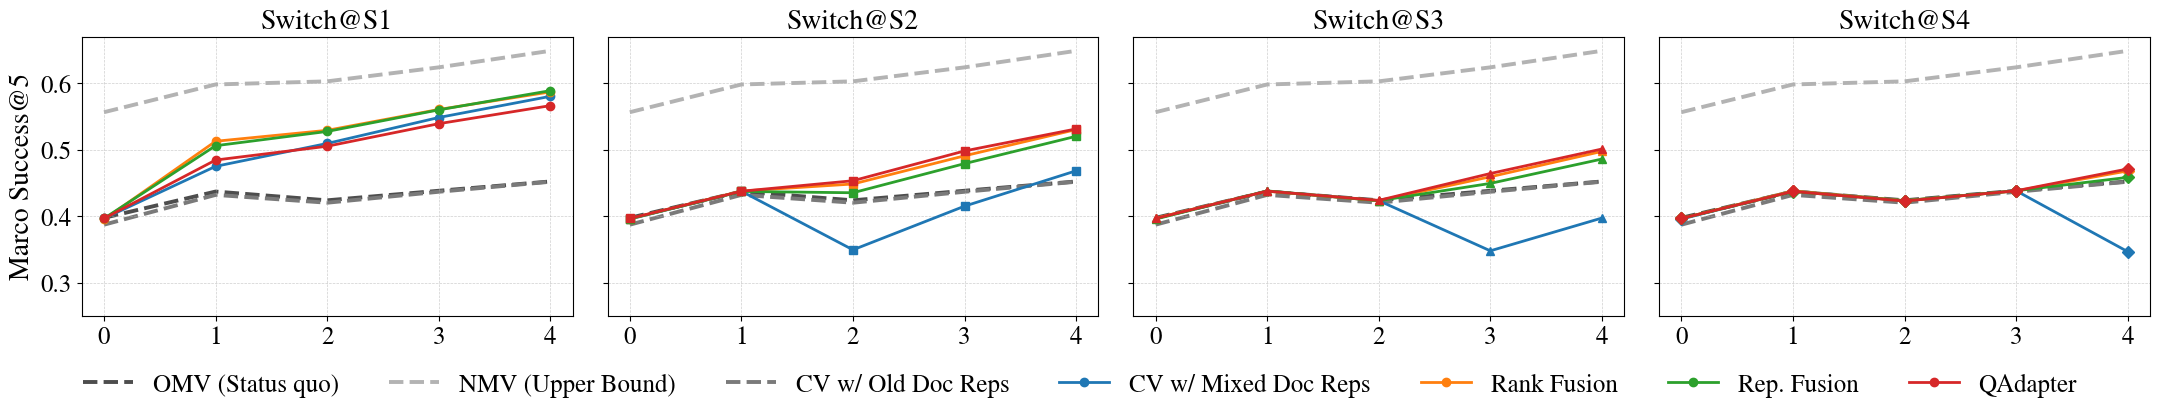

In [2]:
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

# ---- SIGIR/ACM-ish look: Times-like serif + bigger fonts ----
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "Nimbus Roman", "STIXGeneral", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 20,          # 全局默认字号（你想更大就 18/20）
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# X axis
x_labels = ["0", "1", "2", "3", "4"]
x = list(range(len(x_labels)))

sections = {
    "CV w/ Mixed Doc Reps": {
        "old_q/old_d (Lower Bound)": [0.3975, 0.4371, 0.4239, 0.4383, 0.4523],
        "new_q/new_d (Upper Bound)": [0.5567, 0.5985, 0.6032, 0.6243, 0.6492],
        "new_q/old_d":               [0.3872, 0.4321, 0.4203, 0.4368, 0.4519],
        "switch@S1": [0.3966, 0.4751, 0.5096, 0.5487, 0.5806],
        "switch@S2": [0.3956, 0.4376, 0.3493, 0.4151, 0.4684],
        "switch@S3": [0.3966, 0.4378, 0.4234, 0.3478, 0.3972],
        "switch@S4": [0.3956, 0.4383, 0.4233, 0.4383, 0.3466],
    },

    "Rank Fusion": {
        "switch@S1": [0.3951, 0.5129, 0.5294, 0.5608, 0.5873],
        "switch@S2": [0.3961, 0.4378, 0.4485, 0.4910, 0.5305],
        "switch@S3": [0.3970, 0.4376, 0.4234, 0.4594, 0.4976],
        "switch@S4": [0.3966, 0.4381, 0.4234, 0.4381, 0.4682],
    },

    "Rep. Fusion": {
        "switch@S1": [0.3966, 0.5062, 0.5277, 0.5602, 0.5892],
        "switch@S2": [0.3961, 0.4373, 0.4353, 0.4792, 0.5204],
        "switch@S3": [0.3956, 0.4381, 0.4233, 0.4494, 0.4861],
        "switch@S4": [0.3966, 0.4371, 0.4233, 0.4383, 0.4585],
    },

    "QAdapter": {
        "switch@S1": [0.3966, 0.4846, 0.5054, 0.5394, 0.5666],
        "switch@S2": [0.3966, 0.4376, 0.4534, 0.4983, 0.5315],
        "switch@S3": [0.3966, 0.4378, 0.4238, 0.4643, 0.5012],
        "switch@S4": [0.3966, 0.4373, 0.4228, 0.4383, 0.4712],
    },
}

ref = {
    "OMV (Status quo)": sections["CV w/ Mixed Doc Reps"]["old_q/old_d (Lower Bound)"],
    "NMV (Upper Bound)": sections["CV w/ Mixed Doc Reps"]["new_q/new_d (Upper Bound)"],
    "CV w/ Old Doc Reps": sections["CV w/ Mixed Doc Reps"]["new_q/old_d"],
}

REF_COLORS = {
    "OMV (Status quo)": "#4d4d4d",  # darker
    "CV w/ Old Doc Reps": "#7a7a7a",                # mid
    "NMV (Upper Bound)": "#b3b3b3",  # lighter
}

REF_LINESTYLE = "--"
REF_LINEWIDTH = 2.8
# Keep method colors for the switch curves
cycle_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
method_colors = {
    method: cycle_colors[i % len(cycle_colors)]
    for i, method in enumerate(sections.keys())
}

switch_markers = {
    "switch@S1": "o",
    "switch@S2": "s",
    "switch@S3": "^",
    "switch@S4": "D",
}

switches = ["switch@S1", "switch@S2", "switch@S3", "switch@S4"]
scenario_titles = ["Switch@S1", "Switch@S2", "Switch@S3", "Switch@S4"]

fig, axes = plt.subplots(1, 4, figsize=(22, 4), sharey=True)

for ax, sw, title in zip(axes, switches, scenario_titles):
    # Plot reference lines with 3 fixed colors
    for lbl, y in ref.items():
        ax.plot(
            x, y,
            color=REF_COLORS[lbl],
            linestyle=REF_LINESTYLE,
            linewidth=REF_LINEWIDTH,
            marker=None,
            label=lbl,
            zorder=1
        )

    # Plot this switch across all methods (method-colored)
    for method_name, lines in sections.items():
        if sw in lines:
            ax.plot(
                x, lines[sw],
                color=method_colors[method_name],
                marker=switch_markers[sw],
                linewidth=2,
                markersize=6,
                label=method_name,
                zorder=2
            )

    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)

axes[0].set_ylabel("Marco Success@5")

# Shared legend (deduplicated)
handles, labels = [], []
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    for hh, ll in zip(h, l):
        if ll not in labels:
            handles.append(hh)
            labels.append(ll)

fig.legend(
    handles, labels,
    loc="lower center",
    ncol=12,
    frameon=False,
    bbox_to_anchor=(0.5, -0.1)
)

plt.tight_layout()
plt.ylim(0.25, 0.67)
plt.savefig("/ivi/ilps/personal/jqiao/lsr-bc/figures/sp_tiny_stream2.pdf", format="pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()

# stream 3

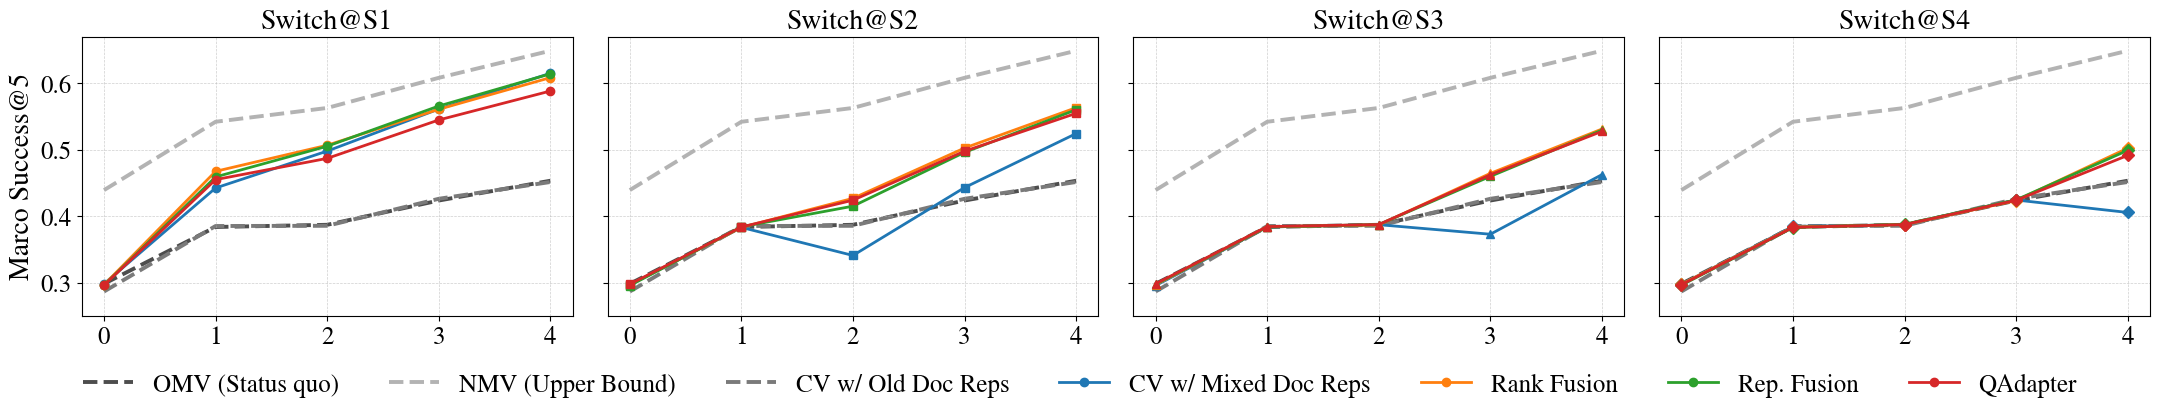

In [3]:
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

# ---- SIGIR/ACM-ish look: Times-like serif + bigger fonts ----
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "Nimbus Roman", "STIXGeneral", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 20,          # 全局默认字号（你想更大就 18/20）
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# X axis
x_labels = ["0", "1", "2", "3", "4"]
x = list(range(len(x_labels)))

sections = {
    "CV w/ Mixed Doc Reps": {
        # Upper/Lower Bound
        "old_q/old_d (Lower Bound)": [0.2981, 0.3837, 0.3870, 0.4236, 0.4534],
        "new_q/new_d (Upper Bound)": [0.4393, 0.5423, 0.5631, 0.6085, 0.6493],
        "new_q/old_d":               [0.2865, 0.3852, 0.3855, 0.4262, 0.4515],
        
        # Experiment 0 without fusion
        "switch@S1": [0.2981, 0.4425, 0.4981, 0.5614, 0.6153],
        "switch@S2": [0.2967, 0.3831, 0.3408, 0.4431, 0.5245],
        "switch@S3": [0.2954, 0.3837, 0.3872, 0.3728, 0.4626],
        "switch@S4": [0.2974, 0.3846, 0.3870, 0.4244, 0.4056],
    },

    "Rank Fusion": {
        "switch@S1": [0.2967, 0.4676, 0.5069, 0.5611, 0.6088],
        "switch@S2": [0.2967, 0.3831, 0.4269, 0.5027, 0.5635],
        "switch@S3": [0.2967, 0.3840, 0.3868, 0.4645, 0.5313],
        "switch@S4": [0.2974, 0.3837, 0.3872, 0.4235, 0.5025],
    },

    "Rep. Fusion": {
        "switch@S1": [0.2960, 0.4592, 0.5054, 0.5660, 0.6145],
        "switch@S2": [0.2954, 0.3840, 0.4151, 0.4962, 0.5604],
        "switch@S3": [0.2974, 0.3837, 0.3874, 0.4600, 0.5297],
        "switch@S4": [0.2960, 0.3828, 0.3878, 0.4246, 0.4992],
    },

    "QAdapter": {
        "switch@S1": [0.2960, 0.4551, 0.4871, 0.5450, 0.5886],
        "switch@S2": [0.2974, 0.3837, 0.4241, 0.4979, 0.5550],
        "switch@S3": [0.2981, 0.3843, 0.3874, 0.4624, 0.5278],
        "switch@S4": [0.2967, 0.3831, 0.3874, 0.4239, 0.4916],
    },
}


ref = {
    "OMV (Status quo)": sections["CV w/ Mixed Doc Reps"]["old_q/old_d (Lower Bound)"],
    "NMV (Upper Bound)": sections["CV w/ Mixed Doc Reps"]["new_q/new_d (Upper Bound)"],
    "CV w/ Old Doc Reps": sections["CV w/ Mixed Doc Reps"]["new_q/old_d"],
}

REF_COLORS = {
    "OMV (Status quo)": "#4d4d4d",  # darker
    "CV w/ Old Doc Reps": "#7a7a7a",                # mid
    "NMV (Upper Bound)": "#b3b3b3",  # lighter
}

REF_LINESTYLE = "--"
REF_LINEWIDTH = 2.8
# Keep method colors for the switch curves
cycle_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
method_colors = {
    method: cycle_colors[i % len(cycle_colors)]
    for i, method in enumerate(sections.keys())
}

switch_markers = {
    "switch@S1": "o",
    "switch@S2": "s",
    "switch@S3": "^",
    "switch@S4": "D",
}

switches = ["switch@S1", "switch@S2", "switch@S3", "switch@S4"]
scenario_titles = ["Switch@S1", "Switch@S2", "Switch@S3", "Switch@S4"]

fig, axes = plt.subplots(1, 4, figsize=(22, 4), sharey=True)

for ax, sw, title in zip(axes, switches, scenario_titles):
    # Plot reference lines with 3 fixed colors
    for lbl, y in ref.items():
        ax.plot(
            x, y,
            color=REF_COLORS[lbl],
            linestyle=REF_LINESTYLE,
            linewidth=REF_LINEWIDTH,
            marker=None,
            label=lbl,
            zorder=1
        )

    # Plot this switch across all methods (method-colored)
    for method_name, lines in sections.items():
        if sw in lines:
            ax.plot(
                x, lines[sw],
                color=method_colors[method_name],
                marker=switch_markers[sw],
                linewidth=2,
                markersize=6,
                label=method_name,
                zorder=2
            )

    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)

axes[0].set_ylabel("Marco Success@5")

# Shared legend (deduplicated)
handles, labels = [], []
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    for hh, ll in zip(h, l):
        if ll not in labels:
            handles.append(hh)
            labels.append(ll)

fig.legend(
    handles, labels,
    loc="lower center",
    ncol=12,
    frameon=False,
    bbox_to_anchor=(0.5, -0.1)
)

plt.tight_layout()
plt.ylim(0.25, 0.67)
plt.savefig("/ivi/ilps/personal/jqiao/lsr-bc/figures/sp_tiny_stream3.pdf", format="pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()

# Average

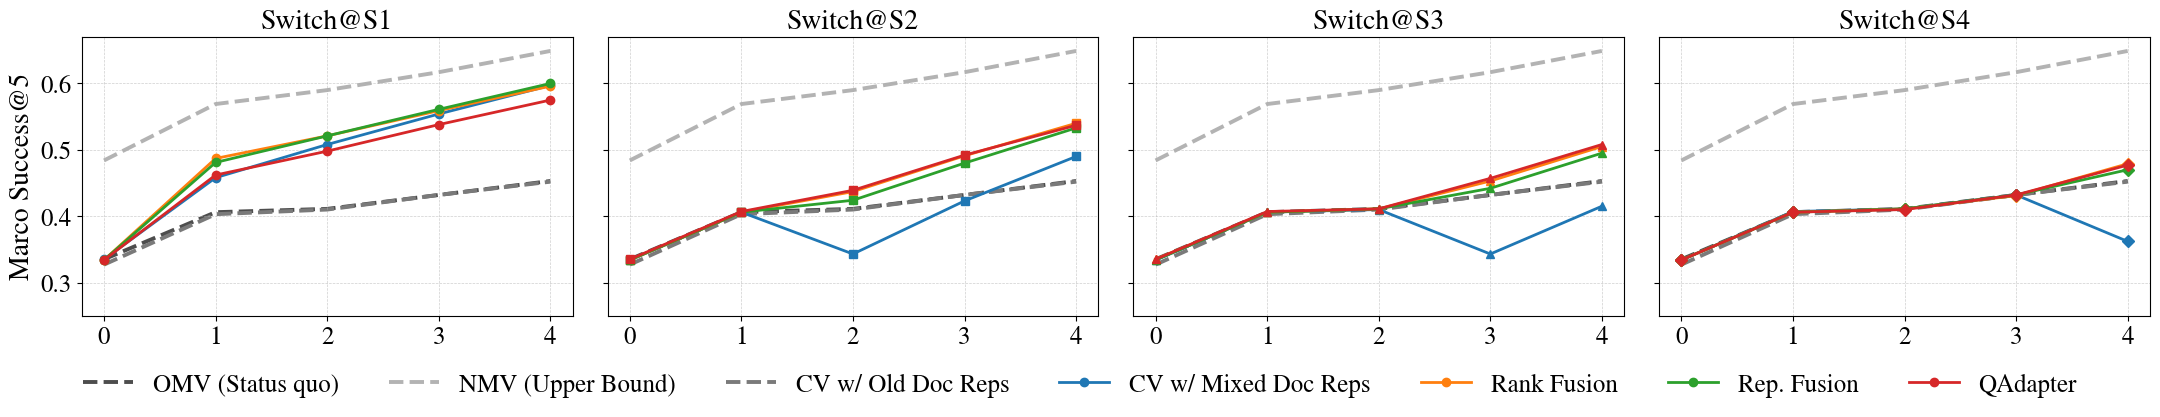

In [4]:
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

# ---- SIGIR/ACM-ish look: Times-like serif + bigger fonts ----
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "Nimbus Roman", "STIXGeneral", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 20,          # 全局默认字号（你想更大就 18/20）
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# X axis
x_labels = ["0", "1", "2", "3", "4"]
x = list(range(len(x_labels)))
sections = {
    "CV w/ Mixed Doc Reps": {
        "old_q/old_d (Lower Bound)": [0.335, 0.406, 0.411, 0.432, 0.453],
        "new_q/new_d (Upper Bound)": [0.484, 0.569, 0.590, 0.617, 0.649],
        "new_q/old_d": [0.327, 0.403, 0.410, 0.432, 0.452],
        "switch@S1": [0.335, 0.458, 0.508, 0.554, 0.597],
        "switch@S2": [0.334, 0.406, 0.343, 0.423, 0.490],
        "switch@S3": [0.334, 0.406, 0.410, 0.343, 0.415],
        "switch@S4": [0.334, 0.407, 0.411, 0.432, 0.362],
    },

    "Rank Fusion": {
        "switch@S1": [0.334, 0.487, 0.521, 0.559, 0.596],
        "switch@S2": [0.334, 0.406, 0.437, 0.491, 0.540],
        "switch@S3": [0.335, 0.406, 0.411, 0.453, 0.505],
        "switch@S4": [0.334, 0.406, 0.411, 0.431, 0.479],
    },

    "Rep. Fusion": {
        "switch@S1": [0.334, 0.481, 0.521, 0.561, 0.600],
        "switch@S2": [0.334, 0.406, 0.424, 0.480, 0.533],
        "switch@S3": [0.334, 0.406, 0.411, 0.442, 0.495],
        "switch@S4": [0.334, 0.406, 0.411, 0.432, 0.470],
    },

    "QAdapter": {
        "switch@S1": [0.334, 0.462, 0.498, 0.538, 0.575],
        "switch@S2": [0.335, 0.407, 0.439, 0.492, 0.537],
        "switch@S3": [0.335, 0.407, 0.411, 0.457, 0.508],
        "switch@S4": [0.334, 0.406, 0.410, 0.432, 0.477],
    },
}



ref = {
    "OMV (Status quo)": sections["CV w/ Mixed Doc Reps"]["old_q/old_d (Lower Bound)"],
    "NMV (Upper Bound)": sections["CV w/ Mixed Doc Reps"]["new_q/new_d (Upper Bound)"],
    "CV w/ Old Doc Reps": sections["CV w/ Mixed Doc Reps"]["new_q/old_d"],
}

REF_COLORS = {
    "OMV (Status quo)": "#4d4d4d",  # darker
    "CV w/ Old Doc Reps": "#7a7a7a",                # mid
    "NMV (Upper Bound)": "#b3b3b3",  # lighter
}

REF_LINESTYLE = "--"
REF_LINEWIDTH = 2.8
# Keep method colors for the switch curves
cycle_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
method_colors = {
    method: cycle_colors[i % len(cycle_colors)]
    for i, method in enumerate(sections.keys())
}

switch_markers = {
    "switch@S1": "o",
    "switch@S2": "s",
    "switch@S3": "^",
    "switch@S4": "D",
}

switches = ["switch@S1", "switch@S2", "switch@S3", "switch@S4"]
scenario_titles = ["Switch@S1", "Switch@S2", "Switch@S3", "Switch@S4"]

fig, axes = plt.subplots(1, 4, figsize=(22, 4), sharey=True)

for ax, sw, title in zip(axes, switches, scenario_titles):
    # Plot reference lines with 3 fixed colors
    for lbl, y in ref.items():
        ax.plot(
            x, y,
            color=REF_COLORS[lbl],
            linestyle=REF_LINESTYLE,
            linewidth=REF_LINEWIDTH,
            marker=None,
            label=lbl,
            zorder=1
        )

    # Plot this switch across all methods (method-colored)
    for method_name, lines in sections.items():
        if sw in lines:
            ax.plot(
                x, lines[sw],
                color=method_colors[method_name],
                marker=switch_markers[sw],
                linewidth=2,
                markersize=6,
                label=method_name,
                zorder=2
            )

    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)

axes[0].set_ylabel("Marco Success@5")

# Shared legend (deduplicated)
handles, labels = [], []
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    for hh, ll in zip(h, l):
        if ll not in labels:
            handles.append(hh)
            labels.append(ll)

fig.legend(
    handles, labels,
    loc="lower center",
    ncol=12,
    frameon=False,
    bbox_to_anchor=(0.5, -0.1)
)

plt.tight_layout()
plt.ylim(0.25, 0.67)
plt.savefig("/ivi/ilps/personal/jqiao/lsr-bc/figures/sp_tiny_avg.pdf", format="pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()

# dense

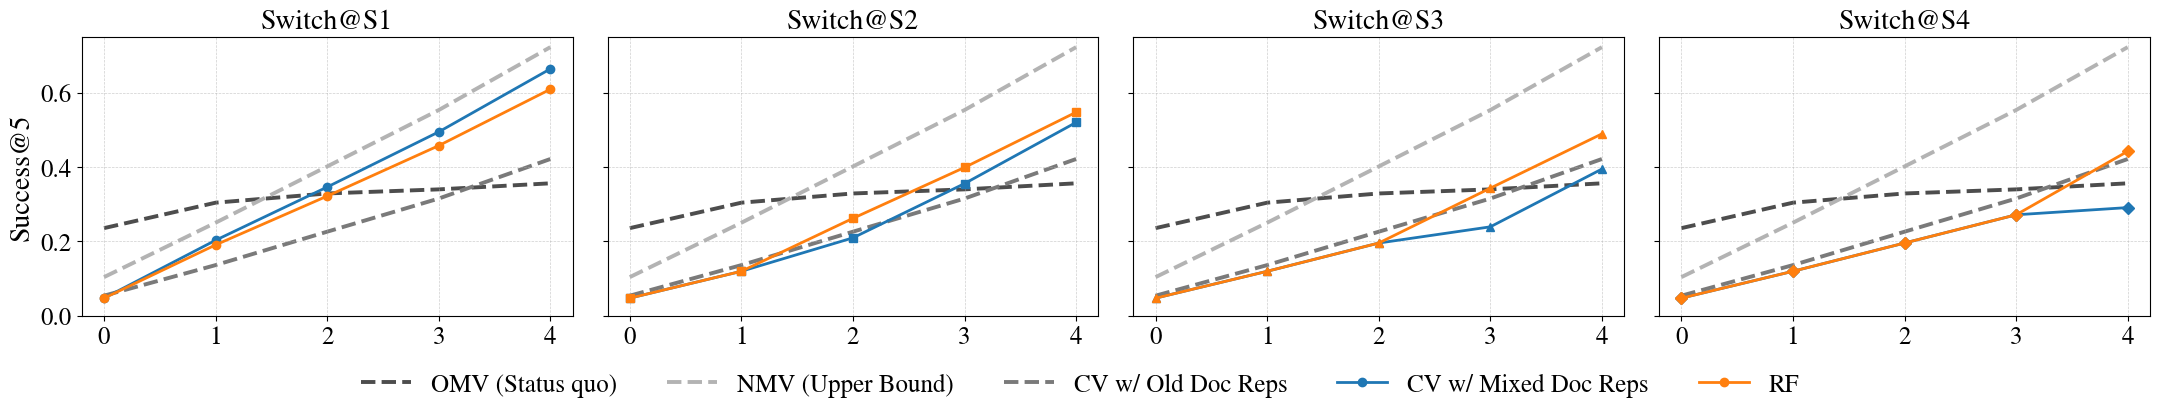

In [5]:
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

# ---- SIGIR/ACM-ish look: Times-like serif + bigger fonts ----
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "Nimbus Roman", "STIXGeneral", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 20,          # 全局默认字号（你想更大就 18/20）
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})



# X axis
x_labels = ["0", "1", "2", "3", "4"]
x = list(range(len(x_labels)))

sections = {
    "CV w/ Mixed Doc Reps": {
        "old_q/old_d (Lower Bound)": [0.2357, 0.3042, 0.329, 0.34, 0.3563],
        "new_q/new_d (Upper Bound)": [0.1039, 0.2503, 0.4017, 0.5535, 0.7227],
        "new_q/old_d": [0.0539, 0.1362, 0.2261, 0.3153, 0.4217],
        "switch@S1": [0.0473, 0.2031, 0.3463, 0.4947, 0.6642],
        "switch@S2": [0.0473, 0.1196, 0.2096, 0.3556, 0.5202],
        "switch@S3": [0.0473, 0.1196, 0.1956, 0.2392, 0.3947],
        "switch@S4": [0.0473, 0.1196, 0.1956, 0.2716, 0.291],
    },

    "RF": {
        "switch@S1": [0.0473, 0.1906, 0.3219, 0.4577, 0.6094],
        "switch@S2": [0.0473, 0.1196, 0.2621, 0.399, 0.5476],
        "switch@S3": [0.0473, 0.1196, 0.1956, 0.3433, 0.4893],
        "switch@S4": [0.0473, 0.1196, 0.1956, 0.2716, 0.4425],
    }
}

# Reference bounds (pulled from No fusion)
ref = {
    "OMV (Status quo)": sections["CV w/ Mixed Doc Reps"]["old_q/old_d (Lower Bound)"],
    "NMV (Upper Bound)": sections["CV w/ Mixed Doc Reps"]["new_q/new_d (Upper Bound)"],
    "CV w/ Old Doc Reps": sections["CV w/ Mixed Doc Reps"]["new_q/old_d"],
}

REF_COLORS = {
    "OMV (Status quo)": "#4d4d4d",  # darker
    "CV w/ Old Doc Reps": "#7a7a7a",                # mid
    "NMV (Upper Bound)": "#b3b3b3",  # lighter
}

REF_LINESTYLE = "--"
REF_LINEWIDTH = 2.8

# Keep method colors for the switch curves
cycle_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
method_colors = {
    method: cycle_colors[i % len(cycle_colors)]
    for i, method in enumerate(sections.keys())
}

switch_markers = {
    "switch@S1": "o",
    "switch@S2": "s",
    "switch@S3": "^",
    "switch@S4": "D",
}

switches = ["switch@S1", "switch@S2", "switch@S3", "switch@S4"]
scenario_titles = ["Switch@S1", "Switch@S2", "Switch@S3", "Switch@S4"]

fig, axes = plt.subplots(1, 4, figsize=(22, 4), sharey=True)

for ax, sw, title in zip(axes, switches, scenario_titles):
    # Plot reference lines with 3 fixed colors
    for lbl, y in ref.items():
        ax.plot(
            x, y,
            color=REF_COLORS[lbl],
            linestyle=REF_LINESTYLE,
            linewidth=REF_LINEWIDTH,
            marker=None,
            label=lbl,
            zorder=1
        )

    # Plot this switch across all methods (method-colored)
    for method_name, lines in sections.items():
        if sw in lines:
            ax.plot(
                x, lines[sw],
                color=method_colors[method_name],
                marker=switch_markers[sw],
                linewidth=2,
                markersize=6,
                label=method_name,
                zorder=2
            )

    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)

axes[0].set_ylabel("Success@5")

# Shared legend (deduplicated)
handles, labels = [], []
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    for hh, ll in zip(h, l):
        if ll not in labels:
            handles.append(hh)
            labels.append(ll)

fig.legend(
    handles, labels,
    loc="lower center",
    ncol=12,
    # fontsize=20,
    frameon=False,
    bbox_to_anchor=(0.5, -0.1)
)

plt.tight_layout()
plt.ylim(0, 0.75)
plt.savefig("/ivi/ilps/personal/jqiao/lsr-bc/figures/MPNet_RF_SQ2_stream1.pdf", format="pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()

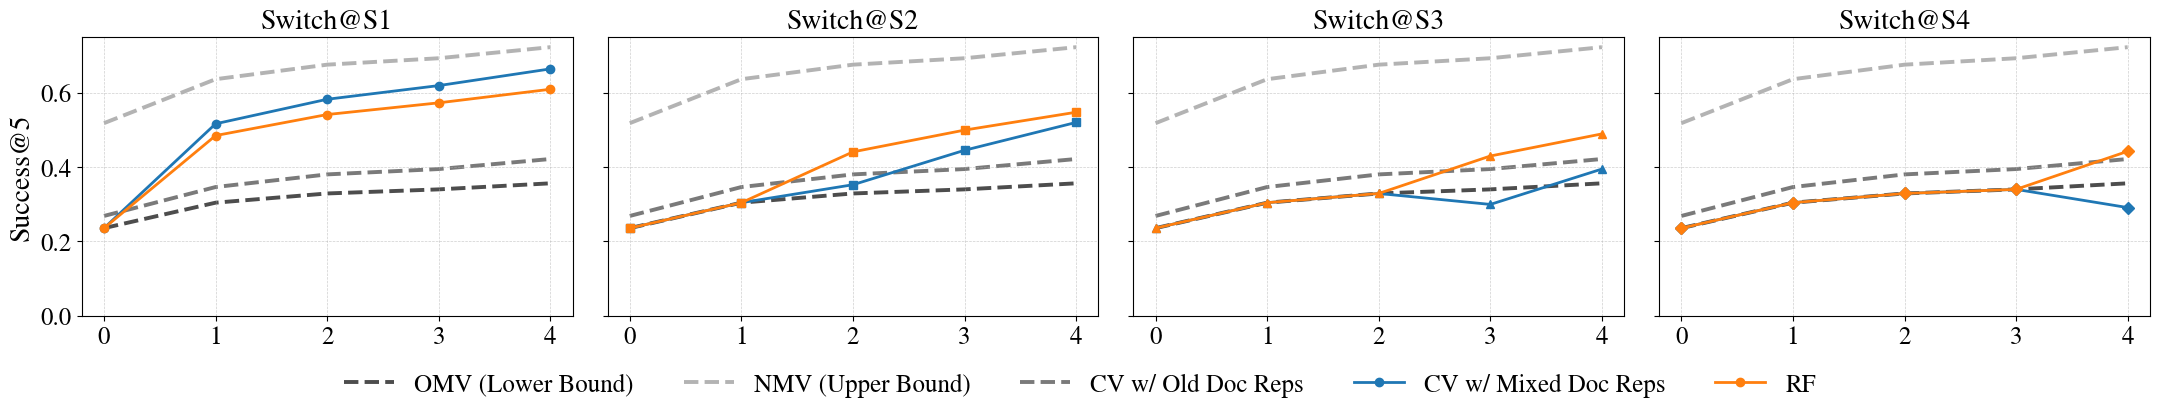

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

# ---- SIGIR/ACM-ish look: Times-like serif + bigger fonts ----
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "Nimbus Roman", "STIXGeneral", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 20,          # 全局默认字号（你想更大就 18/20）
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})



# X axis
x_labels = ["0", "1", "2", "3", "4"]
x = list(range(len(x_labels)))

sections = {
    "CV w/ Mixed Doc Reps": {
        "old_q/old_d (Lower Bound)": [0.2357, 0.3042, 0.329, 0.34, 0.3563],
        "new_q/new_d (Upper Bound)": [0.5182, 0.6365, 0.6756, 0.6929, 0.7227],
        "new_q/old_d": [0.2685, 0.3463, 0.3803, 0.3947, 0.4217],
        # "switch@S1": [0.0473, 0.2031, 0.3463, 0.4947, 0.6642],
        # "switch@S2": [0.0473, 0.1196, 0.2096, 0.3556, 0.5202],
        # "switch@S3": [0.0473, 0.1196, 0.1956, 0.2392, 0.3947],
        # "switch@S4": [0.0473, 0.1196, 0.1956, 0.2716, 0.291],

        "switch@S1": [0.2357, 0.5165, 0.5825, 0.6193, 0.6642],
        "switch@S2": [0.2357, 0.3042, 0.3525, 0.4452, 0.5202],
        "switch@S3": [0.2357, 0.3042, 0.329, 0.2995, 0.3947],
        "switch@S4": [0.2357, 0.3042, 0.329, 0.34, 0.291],
    },
    "RF": {
        # "switch@S1": [0.0473, 0.1906, 0.3219, 0.4577, 0.6094],
        # "switch@S2": [0.0473, 0.1196, 0.2621, 0.399, 0.5476],
        # "switch@S3": [0.0473, 0.1196, 0.1956, 0.3433, 0.4893],
        # "switch@S4": [0.0473, 0.1196, 0.1956, 0.2716, 0.4425],
        "switch@S1": [0.2357, 0.4848, 0.5414, 0.5729, 0.6094],
        "switch@S2": [0.2357, 0.3042, 0.4409, 0.4995, 0.5476],
        "switch@S3": [0.2357, 0.3042, 0.3290, 0.4298, 0.4893],
        "switch@S4": [0.2357, 0.3042, 0.3290, 0.3400, 0.4425],
    }
}

# Reference bounds (pulled from No fusion)
ref = {
    "OMV (Lower Bound)": sections["CV w/ Mixed Doc Reps"]["old_q/old_d (Lower Bound)"],
    "NMV (Upper Bound)": sections["CV w/ Mixed Doc Reps"]["new_q/new_d (Upper Bound)"],
    "CV w/ Old Doc Reps": sections["CV w/ Mixed Doc Reps"]["new_q/old_d"],
}

REF_COLORS = {
    "OMV (Lower Bound)": "#4d4d4d",  # darker
    "CV w/ Old Doc Reps": "#7a7a7a",                # mid
    "NMV (Upper Bound)": "#b3b3b3",  # lighter
}

REF_LINESTYLE = "--"
REF_LINEWIDTH = 2.8

# Keep method colors for the switch curves
cycle_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
method_colors = {
    method: cycle_colors[i % len(cycle_colors)]
    for i, method in enumerate(sections.keys())
}

switch_markers = {
    "switch@S1": "o",
    "switch@S2": "s",
    "switch@S3": "^",
    "switch@S4": "D",
}

switches = ["switch@S1", "switch@S2", "switch@S3", "switch@S4"]
scenario_titles = ["Switch@S1", "Switch@S2", "Switch@S3", "Switch@S4"]

fig, axes = plt.subplots(1, 4, figsize=(22, 4), sharey=True)

for ax, sw, title in zip(axes, switches, scenario_titles):
    # Plot reference lines with 3 fixed colors
    for lbl, y in ref.items():
        ax.plot(
            x, y,
            color=REF_COLORS[lbl],
            linestyle=REF_LINESTYLE,
            linewidth=REF_LINEWIDTH,
            marker=None,
            label=lbl,
            zorder=1
        )

    # Plot this switch across all methods (method-colored)
    for method_name, lines in sections.items():
        if sw in lines:
            ax.plot(
                x, lines[sw],
                color=method_colors[method_name],
                marker=switch_markers[sw],
                linewidth=2,
                markersize=6,
                label=method_name,
                zorder=2
            )

    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)

axes[0].set_ylabel("Success@5")

# Shared legend (deduplicated)
handles, labels = [], []
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    for hh, ll in zip(h, l):
        if ll not in labels:
            handles.append(hh)
            labels.append(ll)

fig.legend(
    handles, labels,
    loc="lower center",
    ncol=12,
    # fontsize=20,
    frameon=False,
    bbox_to_anchor=(0.5, -0.1)
)
plt.tight_layout()
plt.ylim(0, 0.75)
plt.savefig("/ivi/ilps/personal/jqiao/lsr-bc/figures/MPNet_RF_SQ2_stream1.pdf", format="pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()
